In [1]:
# ============================================
# Section 0: Package Import and Global Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, kurtosis

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

from sklearn.covariance import LedoitWolf

from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

# ============================================
# Annualization Parameters
# ============================================

MONTHS_PER_YEAR = 12

# ============================================
# Rolling Window Parameters
# ============================================

ROLLING_WINDOWS = {
    '60m': 60,
    '120m': 120
}

# expanding window will be handled separately


print('Packages loaded successfully.')


Packages loaded successfully.


In [2]:
# ============================================
# Section 1: Import Data
# ============================================

data = pd.read_excel('FactorData.xlsx',index_col='Dates')

data.index = pd.to_datetime(data.index,format='%Y%m')

data.tail()


,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
Dates,,,,,,,,,
2025-08-01,0.018400,0.048200,0.044600,-0.007200,0.019600,-0.036000,-0.022993,0.015925,0.016800
2025-09-01,0.033900,-0.022400,-0.009400,-0.022100,-0.022900,0.046300,0.003199,-0.017724,-0.019900
2025-10-01,0.019600,-0.016100,-0.028000,-0.057700,-0.040500,0.003300,-0.028677,-0.035337,-0.043800
2025-11-01,-0.001300,0.016300,0.035700,0.017100,0.006200,-0.017900,0.002650,0.007241,0.042000
2025-12-01,-0.003600,-0.001700,0.023600,0.004400,0.004000,-0.023300,-0.002974,0.005061,0.006200


In [3]:
# ============================================
# Section 2: Utility Functions
# ============================================

# --------------------------------------------
# Performance Metrics
# --------------------------------------------

def annualized_return(x):

    return x.mean() * 12


def annualized_volatility(x):

    return x.std() * np.sqrt(12)


def sharpe_ratio(x):

    return annualized_return(x) / annualized_volatility(x)


def skewness(x):

    return skew(x)


def kurtosis_value(x):

    return kurtosis(x)


# --------------------------------------------
# Summary Statistics Table
# --------------------------------------------

def performance_summary(x):

    summary = pd.Series({
        'Mean': annualized_return(x),
        'Volatility': annualized_volatility(x),
        'Sharpe Ratio': sharpe_ratio(x),
        'Skewness': skewness(x),
        'Kurtosis': kurtosis_value(x)
    })

    return summary


# --------------------------------------------
# Jobson-Korkie Test with Memmel Correction
# --------------------------------------------

def jobson_korkie_test(r1, r2):

    r1 = pd.Series(r1).dropna()
    r2 = pd.Series(r2).dropna()
    
    # align by index (BEST PRACTICE)
    r1, r2 = r1.align(r2, join = 'inner')


    sr1 = sharpe_ratio(pd.Series(r1))
    sr2 = sharpe_ratio(pd.Series(r2))

    T = len(r1)

    rho = np.corrcoef(r1, r2)[0,1]

    theta = (
        (1 / T) *
        (
            2 * (1 - rho)
            + 0.5 * (
                sr1**2 +
                sr2**2 -
                2 * rho * sr1 * sr2
            )
        )
    )

    z_stat = (sr1 - sr2) / np.sqrt(theta)

    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return pd.Series({
        'SR1': sr1,
        'SR2': sr2,
        'SR Difference': sr1 - sr2,
        'Z-Statistic': z_stat,
        'P-Value': p_value
    })

# ============================================
# Significance Star Function
# ============================================

def significance_stars(p_value):

    if p_value < 0.01:
        return '***'
    elif p_value < 0.05:
        return '**'
    elif p_value < 0.10:
        return '*'
    else:
        return ''


In [4]:
# ============================================
# Section 3: Original Factor Performance
# ============================================

# --------------------------------------------
# Individual Factor Performance
# --------------------------------------------

factor_performance = pd.DataFrame()

for factor in data.columns:

    factor_performance[factor] = performance_summary(data[factor])

factor_performance = factor_performance.T

factor_performance


,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Market,0.071404,0.157458,0.453481,-0.497682,1.624119
SMB,0.015417,0.107045,0.144021,0.503303,4.904698
HML,0.032670,0.106243,0.307502,0.050188,2.114115
RMW,0.034192,0.077764,0.439693,-0.230331,10.142018
CMA,0.031526,0.073073,0.431431,0.293561,1.423329
UMD,0.070642,0.147057,0.480372,-1.284357,9.557441
ROE,0.061229,0.087746,0.697791,-0.882070,5.507162
IA,0.040039,0.067799,0.590549,0.144525,1.177221
BAB,0.097130,0.114390,0.849118,-0.450871,4.034836


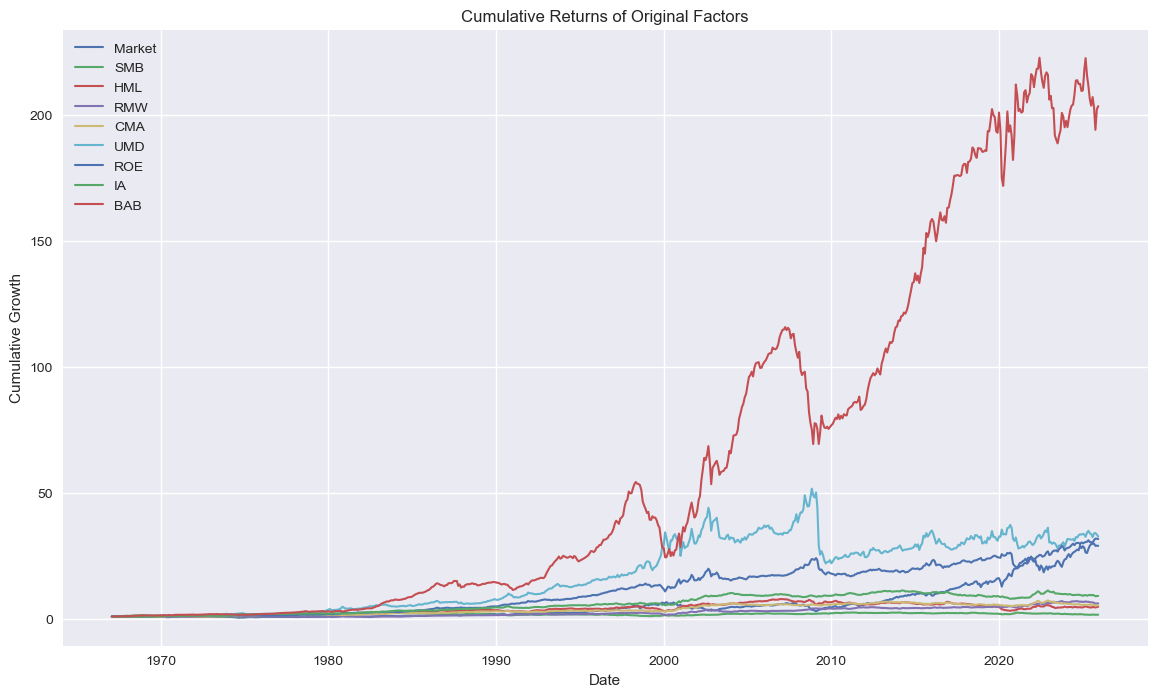

In [5]:
# ============================================
# Figure: Cumulative Returns of Original Factors
# ============================================

cumulative_returns = (1 + data).cumprod()

plt.figure(figsize=(14,8))

for factor in data.columns:

    plt.plot(
        cumulative_returns.index,
        cumulative_returns[factor],
        label=factor,
        linewidth=1.5
    )

plt.title('Cumulative Returns of Original Factors')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')
plt.legend()
plt.grid(True)

plt.show()

In [6]:
# ============================================
# Section 4: Equal-Weight Benchmark
# ============================================

# --------------------------------------------
# 1/N Portfolio Returns
# --------------------------------------------

equal_weight_returns = data.mean(axis=1)

equal_weight_summary = performance_summary(equal_weight_returns) 

equal_weight_summary


Mean            0.050472
Volatility      0.039883
Sharpe Ratio    1.265510
Skewness       -0.257508
Kurtosis        6.387285
dtype: float64

In [7]:
# ============================================
# Add 1/N Portfolio to Factor Table
# ============================================

factor_performance_extended = factor_performance.copy()

factor_performance_extended.loc['1/N Portfolio'] = equal_weight_summary

factor_performance_extended

,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Market,0.071404,0.157458,0.453481,-0.497682,1.624119
SMB,0.015417,0.107045,0.144021,0.503303,4.904698
HML,0.032670,0.106243,0.307502,0.050188,2.114115
RMW,0.034192,0.077764,0.439693,-0.230331,10.142018
CMA,0.031526,0.073073,0.431431,0.293561,1.423329
UMD,0.070642,0.147057,0.480372,-1.284357,9.557441
ROE,0.061229,0.087746,0.697791,-0.882070,5.507162
IA,0.040039,0.067799,0.590549,0.144525,1.177221
BAB,0.097130,0.114390,0.849118,-0.450871,4.034836
1/N Portfolio,0.050472,0.039883,1.265510,-0.257508,6.387285


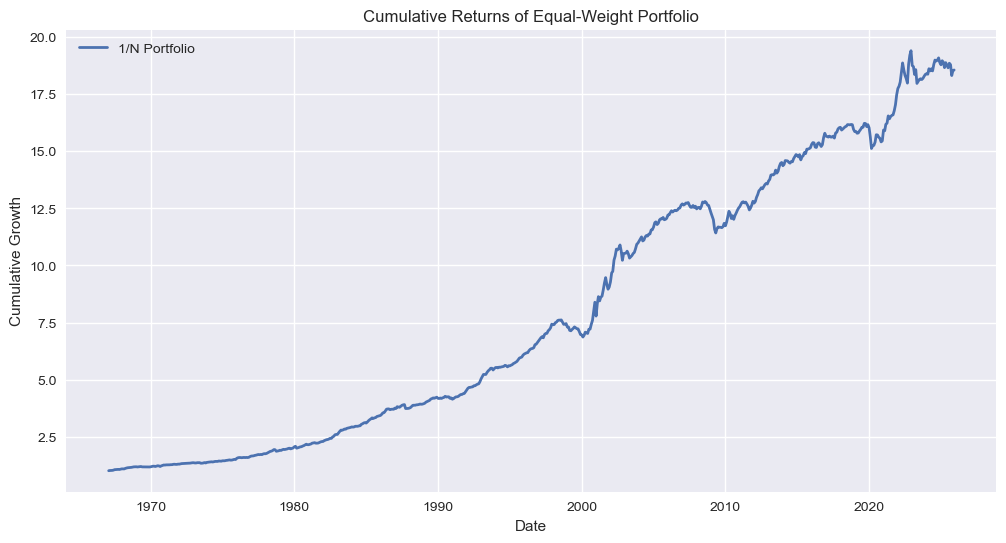

In [8]:
# ============================================
# Figure: 1/N Benchmark Performance
# ============================================

equal_weight_cumulative = (1 + equal_weight_returns).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    equal_weight_cumulative.index,
    equal_weight_cumulative,
    linewidth=2,
    label='1/N Portfolio'
)

plt.title('Cumulative Returns of Equal-Weight Portfolio')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()

In [9]:
# ============================================
# Section 5: Parametric Portfolio
# ============================================

# --------------------------------------------
# In-Sample Mean-Variance Portfolio
# --------------------------------------------

mean_returns = data.mean()

cov_matrix = data.cov()

inv_cov_matrix = np.linalg.inv(cov_matrix)

# unconstrained tangency weights

parametric_weights_unconstrained = (
    inv_cov_matrix @ mean_returns
)

parametric_weights_unconstrained = (
    parametric_weights_unconstrained /
    parametric_weights_unconstrained.sum()
)

parametric_weights_unconstrained = pd.Series(
    parametric_weights_unconstrained,
    index=data.columns
)

# portfolio returns

parametric_returns_unconstrained = (
    data @ parametric_weights_unconstrained
)

# summary statistics

parametric_summary_unconstrained = performance_summary(
    parametric_returns_unconstrained
)

print(parametric_weights_unconstrained)

parametric_summary_unconstrained


Market    0.152163
SMB       0.118346
HML       0.020373
RMW      -0.013776
CMA      -0.109434
UMD       0.025905
ROE       0.277717
IA        0.421920
BAB       0.106785
dtype: float64


Mean            0.055534
Volatility      0.039655
Sharpe Ratio    1.400429
Skewness       -0.309593
Kurtosis        3.279967
dtype: float64

In [10]:
# ============================================
# Constrained Sharpe Optimization (KKT)
# ============================================

market_weight = 1

non_market_factors = data.columns.drop('Market')

mu_full = mean_returns.values
cov_full = cov_matrix.values

n = len(data.columns)

market_idx = list(data.columns).index('Market')

inv_cov = np.linalg.inv(cov_full)

e_market = np.zeros(n)
e_market[market_idx] = 1


from scipy.optimize import minimize

# we maximize Sharpe -> minimize negative Sharpe

def objective(x):
    mu_p = mu_full @ x
    sigma_p = x.T @ cov_full @ x
    return - mu_p / np.sqrt(sigma_p)

# constraint: market = 1
constraints = ({
    'type': 'eq',
    'fun': lambda x: x[market_idx] - market_weight
})

x0 = np.ones(n) / n

result = minimize(
    objective,
    x0=x0,
    constraints=constraints,
    method='SLSQP'
)

parametric_weights_constrained = pd.Series(
    result.x,
    index=data.columns
)

# portfolio returns

parametric_returns_constrained = (
    data @ parametric_weights_constrained
)

# summary statistics

parametric_summary_constrained = performance_summary(
    parametric_returns_constrained
)

print(parametric_weights_constrained)

parametric_summary_constrained

Market    1.000000
SMB       0.780543
HML       0.131940
RMW      -0.088480
CMA      -0.725765
UMD       0.169852
ROE       1.826682
IA        2.781999
BAB       0.705901
dtype: float64


Mean            0.365639
Volatility      0.261091
Sharpe Ratio    1.400427
Skewness       -0.309195
Kurtosis        3.281944
dtype: float64

In [11]:
# ============================================
# Parametric Portfolio Comparison Table
# ============================================

parametric_table = pd.DataFrame({
    'Unconstrained': parametric_summary_unconstrained,
    'Constrained': parametric_summary_constrained
}).T

parametric_table

,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Unconstrained,0.055534,0.039655,1.400429,-0.309593,3.279967
Constrained,0.365639,0.261091,1.400427,-0.309195,3.281944


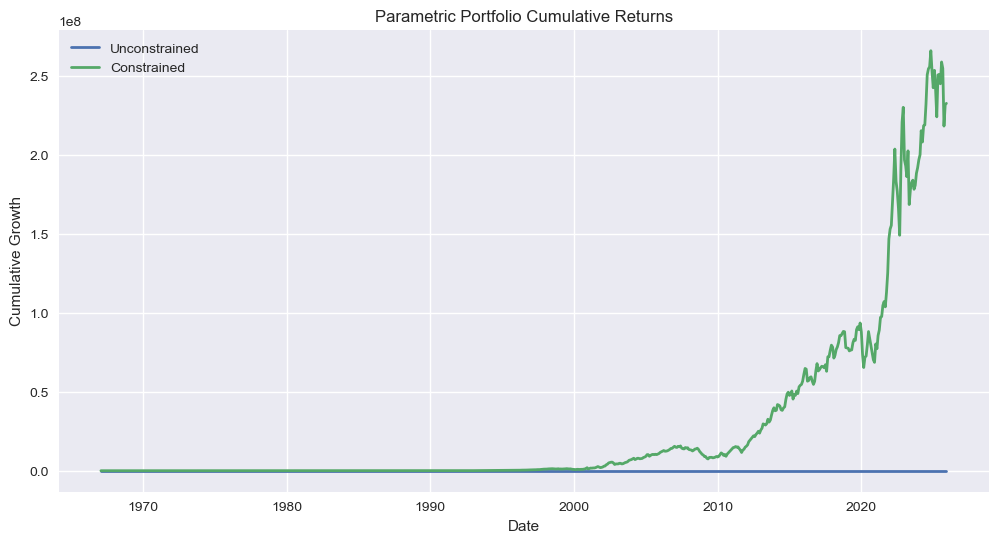

In [12]:
# ============================================
# Figure: Parametric Portfolio Cumulative Returns
# ============================================

parametric_cumulative_unconstrained = (
    1 + parametric_returns_unconstrained
).cumprod()

parametric_cumulative_constrained = (
    1 + parametric_returns_constrained
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    parametric_cumulative_unconstrained.index,
    parametric_cumulative_unconstrained,
    label='Unconstrained',
    linewidth=2
)

plt.plot(
    parametric_cumulative_constrained.index,
    parametric_cumulative_constrained,
    label='Constrained',
    linewidth=2
)

plt.title('Parametric Portfolio Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()

In [13]:

# ============================================
# Section 6: Rolling Out-of-Sample Framework
# ============================================

def rolling_oos_performance(data, window=120, constrained=False):

    oos_returns = []

    oos_dates = []

    oos_weights = []

    for t in range(window, len(data)-1):

        # estimation window

        train_data = data.iloc[t-window:t]

        # next month return

        test_return = data.iloc[t]

        # estimate moments

        mu = train_data.mean()

        sigma = train_data.cov()

        inv_sigma = np.linalg.inv(sigma)

        # unconstrained portfolio

        if constrained == False:

            weights = inv_sigma @ mu

            weights = weights / weights.sum()

            weights = pd.Series(
                weights,
                index=data.columns
            )

        # constrained portfolio

        else:

            market_weight = 1
            market_idx = data.columns.get_loc('Market')

            mu_full = mu.values
            sigma_full = sigma.values

            n = len(data.columns)

            # Sharpe objective (nonlinear)
            def objective(x):
                port_mu = mu_full @ x
                port_var = x.T @ sigma_full @ x
                return -port_mu / np.sqrt(port_var)

            # constraint: market exposure fixed
            constraints = ({
                'type': 'eq',
                'fun': lambda x: x[market_idx] - market_weight
            })

            # initial guess
            x0 = np.ones(n) / n

            result = minimize(
                objective,
                x0=x0,
                constraints=constraints,
                method='SLSQP'
            )

            weights = pd.Series(
                result.x,
                index=data.columns
            )

        # OOS return

        portfolio_return = np.dot(
            weights,
            test_return
        )

        oos_returns.append(portfolio_return)

        oos_dates.append(data.index[t])

        oos_weights.append(weights)

    oos_returns = pd.Series(
        oos_returns,
        index=oos_dates
    )

    oos_weights = pd.DataFrame(
        oos_weights,
        index=oos_dates
    )

    return oos_returns, oos_weights

In [14]:
# ============================================
# 120-Month OOS Performance
# ============================================

oos_returns_unconstrained_120, oos_weights_unconstrained_120 = (
    rolling_oos_performance(
        data,
        window=120,
        constrained=False
    )
)

oos_returns_constrained_120, oos_weights_constrained_120 = (
    rolling_oos_performance(
        data,
        window=120,
        constrained=True
    )
)

# summary statistics

oos_summary_unconstrained_120 = performance_summary(
    oos_returns_unconstrained_120
)

oos_summary_constrained_120 = performance_summary(
    oos_returns_constrained_120
)

oos_table_120 = pd.DataFrame({
    'Unconstrained': oos_summary_unconstrained_120,
    'Constrained': oos_summary_constrained_120
}).T

oos_table_120

,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Unconstrained,0.049356,0.050033,0.986477,0.009570,8.794005
Constrained,356.368604,408.680951,0.871997,3.833154,22.484323


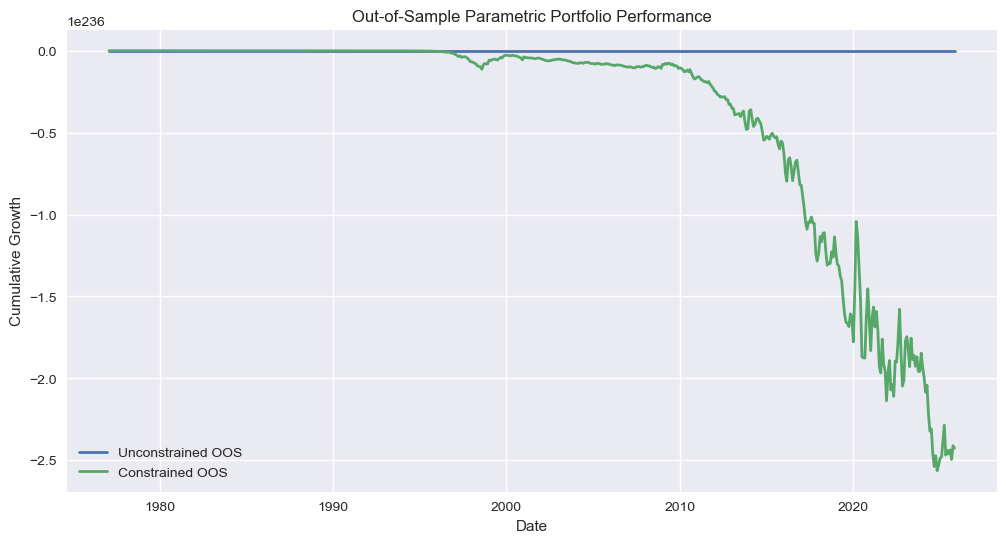

In [15]:
# ============================================
# Figure: OOS Parametric Portfolio Performance
# ============================================

oos_cumulative_unconstrained_120 = (
    1 + oos_returns_unconstrained_120
).cumprod()

oos_cumulative_constrained_120 = (
    1 + oos_returns_constrained_120
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    oos_cumulative_unconstrained_120.index,
    oos_cumulative_unconstrained_120,
    linewidth=2,
    label='Unconstrained OOS'
)

plt.plot(
    oos_cumulative_constrained_120.index,
    oos_cumulative_constrained_120,
    linewidth=2,
    label='Constrained OOS'
)

plt.title('Out-of-Sample Parametric Portfolio Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()

In [60]:

# ============================================
# Section 7: Statistical Inference
# ============================================

# --------------------------------------------
# Parametric Portfolio vs 1/N Benchmark
# --------------------------------------------

equal_weight_oos = equal_weight_returns.loc[
    oos_returns_unconstrained_120.index
]

jk_test_equal_weight = jobson_korkie_test(
    oos_returns_unconstrained_120,
    equal_weight_oos
)

jk_test_equal_weight

SR1              0.986477
SR2              1.202721
SR Difference   -0.216244
Z-Statistic     -4.469274
P-Value          0.000008
dtype: float64

In [17]:
# ============================================
# Parametric Portfolio vs Individual Factors
# ============================================

factor_sr_tests = pd.DataFrame()

for factor in data.columns:

    aligned_factor = data.loc[
        oos_returns_unconstrained_120.index,
        factor
    ]

    test_result = jobson_korkie_test(
        oos_returns_unconstrained_120,
        aligned_factor
    )

    factor_sr_tests[factor] = test_result

factor_sr_tests = factor_sr_tests.T

factor_sr_tests['Significance'] = (
    factor_sr_tests['P-Value']
    .apply(significance_stars)
)

factor_sr_tests

,SR1,SR2,SR Difference,Z-Statistic,P-Value,Significance
Market,0.986477,0.546902,0.439576,7.383924,0.000000,***
SMB,0.986477,0.140619,0.845859,13.079100,0.000000,***
HML,0.986477,0.216568,0.769909,12.587130,0.000000,***
RMW,0.986477,0.517146,0.469331,7.964842,0.000000,***
CMA,0.986477,0.353185,0.633292,11.014364,0.000000,***
UMD,0.986477,0.448855,0.537623,9.088296,0.000000,***
ROE,0.986477,0.736525,0.249952,4.359355,0.000013,***
IA,0.986477,0.480519,0.505959,8.762381,0.000000,***
BAB,0.986477,0.821906,0.164571,3.108259,0.001882,***


In [18]:
# ============================================
# Section 8: Volatility-Managed Factors
# ============================================

def volatility_managed_factors(data, window=12):

    vm_returns = pd.DataFrame(
        index=data.index,
        columns=data.columns
    )

    for factor in data.columns:

        rolling_variance = (
            data[factor]
            .rolling(window)
            .var()
        )

        # avoid extremely small variance

        rolling_variance = rolling_variance.clip(
            lower=1e-6
        )

        scaling_weight = 1 / rolling_variance

        scaling_weight = scaling_weight.shift(1)

        # normalize scaling weights

        scaling_weight = (
            scaling_weight /
            scaling_weight.mean()
        )

        vm_returns[factor] = (
            scaling_weight * data[factor]
        )

    vm_returns = vm_returns.dropna()

    return vm_returns

In [19]:
# ============================================
# Volatility-Managed Factor Returns
# ============================================

vm_data = volatility_managed_factors(
    data,
    window=12
)

# --------------------------------------------
# VM Factor Performance
# --------------------------------------------

vm_performance = pd.DataFrame()

for factor in vm_data.columns:

    vm_performance[factor] = performance_summary(
        vm_data[factor]
    )

vm_performance = vm_performance.T

vm_performance

,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Market,0.061760,0.161537,0.382329,1.870834,25.719789
SMB,0.008990,0.120273,0.074743,1.498836,17.083526
HML,0.012594,0.097390,0.129320,0.377967,7.283586
RMW,0.029490,0.063123,0.467186,-0.283119,9.892802
CMA,0.019479,0.063288,0.307779,0.111219,2.883309
UMD,0.093771,0.137323,0.682847,0.832498,15.738842
ROE,0.075168,0.078865,0.953130,1.291039,7.304535
IA,0.030848,0.060287,0.511686,0.028926,2.897267
BAB,0.083155,0.098637,0.843040,0.123552,7.314280


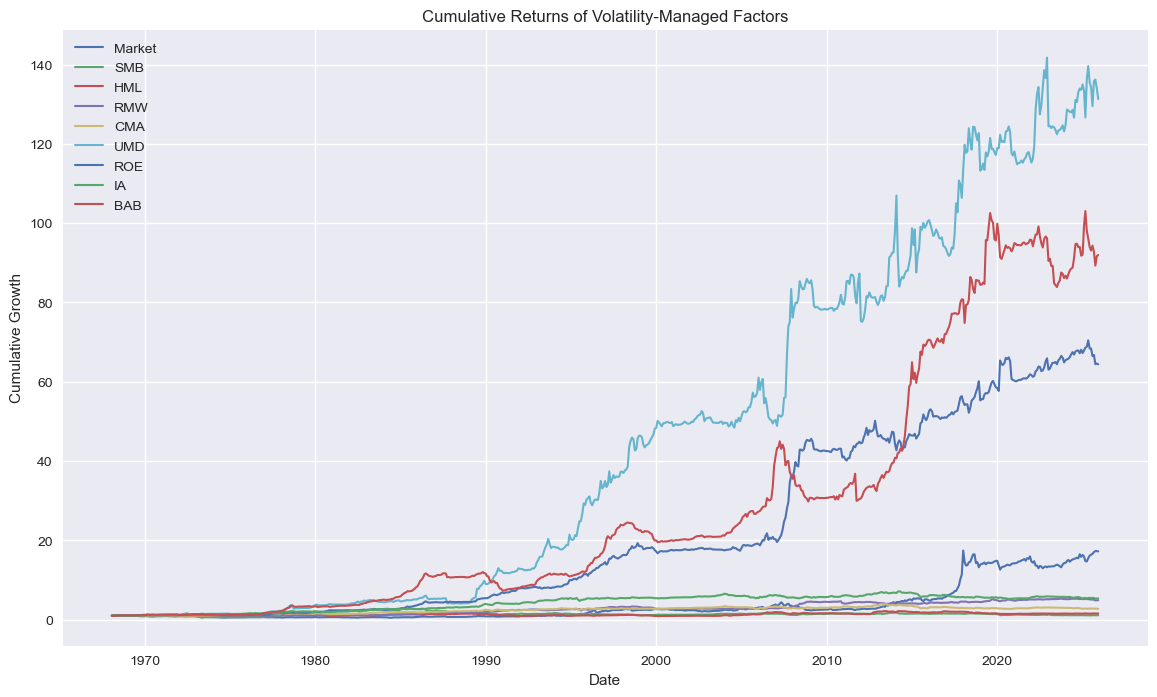

In [20]:
# ============================================
# Figure: Volatility-Managed Factors
# ============================================

vm_cumulative = (1 + vm_data).cumprod()

plt.figure(figsize=(14,8))

for factor in vm_data.columns:

    plt.plot(
        vm_cumulative.index,
        vm_cumulative[factor],
        linewidth=1.5,
        label=factor
    )

plt.title('Cumulative Returns of Volatility-Managed Factors')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# ============================================
# Section 9: VM Statistical Inference
# ============================================

vm_sr_tests = pd.DataFrame()

for factor in data.columns:

    # align dates

    original_factor = data.loc[
        vm_data.index,
        factor
    ]

    vm_factor = vm_data[factor]

    # Sharpe ratio difference test

    test_result = jobson_korkie_test(
        original_factor,
        vm_factor
    )

    vm_sr_tests[factor] = test_result

vm_sr_tests = vm_sr_tests.T

vm_sr_tests['Significance'] = (
    vm_sr_tests['P-Value']
    .apply(significance_stars)
)

vm_sr_tests

,SR1,SR2,SR Difference,Z-Statistic,P-Value,Significance
Market,0.448491,0.382329,0.066162,2.242406,0.024935,**
SMB,0.095809,0.074743,0.021067,0.706563,0.479838,
HML,0.314714,0.129320,0.185394,6.132173,0.000000,***
RMW,0.443879,0.467186,-0.023307,-0.673866,0.500397,
CMA,0.446725,0.307779,0.138946,4.799567,0.000002,***
UMD,0.467674,0.682847,-0.215173,-5.824813,0.000000,***
ROE,0.688856,0.953130,-0.264275,-7.361187,0.000000,***
IA,0.605863,0.511686,0.094178,3.259317,0.001117,***
BAB,0.829616,0.843040,-0.013424,-0.341999,0.732352,


In [22]:
# ============================================
# Original vs VM Comparison Table
# ============================================

comparison_table = pd.DataFrame(index=data.columns)

comparison_table['Original SR'] = [
    sharpe_ratio(data[factor])
    for factor in data.columns
]

comparison_table['VM SR'] = [
    sharpe_ratio(vm_data[factor])
    for factor in data.columns
]

comparison_table['SR Difference'] = (
    comparison_table['VM SR']
    - comparison_table['Original SR']
)

comparison_table['P-Value'] = (
    vm_sr_tests['P-Value']
)

comparison_table['Significance'] = (
    vm_sr_tests['Significance']
)

comparison_table

,Original SR,VM SR,SR Difference,P-Value,Significance
Market,0.453481,0.382329,-0.071152,0.024935,**
SMB,0.144021,0.074743,-0.069278,0.479838,
HML,0.307502,0.129320,-0.178183,0.000000,***
RMW,0.439693,0.467186,0.027492,0.500397,
CMA,0.431431,0.307779,-0.123653,0.000002,***
UMD,0.480372,0.682847,0.202475,0.000000,***
ROE,0.697791,0.953130,0.255340,0.000000,***
IA,0.590549,0.511686,-0.078863,0.001117,***
BAB,0.849118,0.843040,-0.006078,0.732352,


In [23]:
# ============================================
# Section 10: ST1 Rolling Combination
# ============================================

def rolling_oos_st1(original_data, vm_data, window=120, constrained=False):

    portfolio_returns = []
    portfolio_dates = []
    portfolio_weights = []
    factor_combination_weights_history = {}

    common_index = original_data.index.intersection(vm_data.index)

    original_data = original_data.loc[common_index]
    vm_data = vm_data.loc[common_index]

    for t in range(window, len(common_index)):

        train_index = common_index[t-window:t]
        test_date = common_index[t]

        combined_train = pd.DataFrame(
            index=train_index,
            columns=original_data.columns
        )

        combined_test_return = pd.Series(
            index=original_data.columns,
            dtype=float
        )

        factor_combination_weights = {}

        # ------------------------------------
        # Step 1: construct rolling combined factors
        # ------------------------------------

        for factor in original_data.columns:

            temp_train = pd.concat(
                [
                    original_data.loc[train_index, factor],
                    vm_data.loc[train_index, factor]
                ],
                axis=1
            )

            temp_train.columns = ['Original', 'VM']

            mu_pair = temp_train.mean()
            sigma_pair = temp_train.cov()

            weights_pair = np.linalg.pinv(sigma_pair) @ mu_pair
            weights_pair = weights_pair / weights_pair.sum()

            factor_combination_weights[factor] = weights_pair

            combined_train[factor] = temp_train @ weights_pair

            temp_test = np.array([
                original_data.loc[test_date, factor],
                vm_data.loc[test_date, factor]
            ])

            combined_test_return[factor] = weights_pair @ temp_test

        factor_combination_weights_history[test_date] = factor_combination_weights

        # ------------------------------------
        # Step 2: parametric portfolio on combined factors
        # ------------------------------------

        mu = combined_train.mean()
        sigma = combined_train.cov()

        if constrained == False:

            weights = np.linalg.pinv(sigma) @ mu
            weights = weights / weights.sum()

            weights = pd.Series(
                weights,
                index=original_data.columns
            )

        else:

            market_weight = 1

            non_market = original_data.columns.drop('Market')

            mu_non_market = mu[non_market]

            sigma_non_market = sigma.loc[
                non_market,
                non_market
            ]

            weights_non_market = (
                np.linalg.pinv(sigma_non_market) @ mu_non_market
            )

            weights_non_market = (
                weights_non_market /
                np.sum(np.abs(weights_non_market))
            )

            weights = pd.Series(
                0.0,
                index=original_data.columns
            )

            weights['Market'] = market_weight
            weights[non_market] = weights_non_market

        portfolio_return = weights @ combined_test_return

        portfolio_returns.append(portfolio_return)
        portfolio_dates.append(test_date)
        portfolio_weights.append(weights)

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=portfolio_dates
    )

    portfolio_weights = pd.DataFrame(
        portfolio_weights,
        index=portfolio_dates,
        columns=original_data.columns
    )

    return portfolio_returns, portfolio_weights, factor_combination_weights_history

In [24]:

# ============================================
# ST1 Parametric Portfolio
# ============================================

(
    st1_returns_unconstrained,
    st1_weights_unconstrained,
    st1_combination_weights
) = rolling_oos_st1(
    data,
    vm_data,
    window=120,
    constrained=False
)

(
    st1_returns_constrained,
    st1_weights_constrained,
    _
) = rolling_oos_st1(
    data,
    vm_data,
    window=120,
    constrained=True
)

st1_summary_unconstrained = performance_summary(
    st1_returns_unconstrained
)

st1_summary_constrained = performance_summary(
    st1_returns_constrained
)

st1_table = pd.DataFrame({
    'Unconstrained': st1_summary_unconstrained,
    'Constrained': st1_summary_constrained
}).T

st1_table


,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Unconstrained,0.057927,0.058476,0.990611,0.238508,3.760180
Constrained,-14.218962,103.918161,-0.136828,-23.884997,569.012391


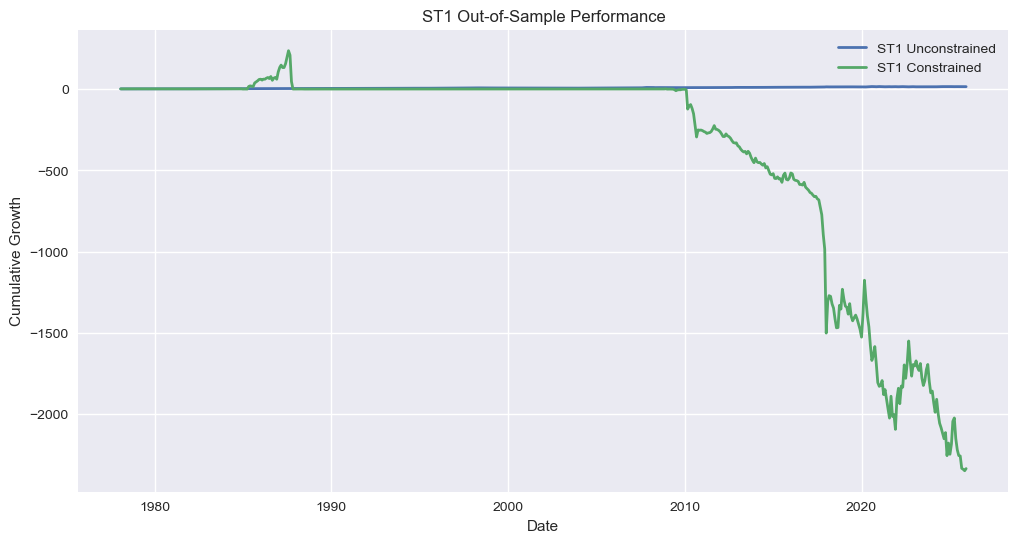

In [25]:

# ============================================
# Figure: ST1 Performance
# ============================================

st1_cumulative_unconstrained = (
    1 + st1_returns_unconstrained
).cumprod()

st1_cumulative_constrained = (
    1 + st1_returns_constrained
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    st1_cumulative_unconstrained.index,
    st1_cumulative_unconstrained,
    linewidth=2,
    label='ST1 Unconstrained'
)

plt.plot(
    st1_cumulative_constrained.index,
    st1_cumulative_constrained,
    linewidth=2,
    label='ST1 Constrained'
)

plt.title('ST1 Out-of-Sample Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()



In [26]:
# ============================================
# Section 11A: ST2 Fixed Selection
# ============================================

selected_vm_factors_fix = []

for factor in data.columns:

    original_sr = sharpe_ratio(
        data.loc[vm_data.index, factor]
    )

    vm_sr = sharpe_ratio(
        vm_data[factor]
    )

    if vm_sr > original_sr:

        selected_vm_factors_fix.append(factor)

selected_vm_factors_fix


['RMW', 'UMD', 'ROE', 'BAB']

In [27]:
# ============================================
# Construct ST2 Fixed Factors
# ============================================

st2_data_fix = data.loc[vm_data.index].copy()

for factor in selected_vm_factors_fix:

    st2_data_fix[factor] = vm_data[factor]

print('Selected VM Factors (Fixed Selection):')
print(selected_vm_factors_fix)

st2_data_fix.head()

Selected VM Factors (Fixed Selection):
['RMW', 'UMD', 'ROE', 'BAB']


,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
Dates,,,,,,,,,
1968-02-01,-0.037500,-0.029500,0.011700,-0.000772,0.024900,-0.028894,-0.003531,0.027512,0.015644
1968-03-01,0.002000,-0.012800,-0.005900,0.007161,-0.011500,0.023360,0.020481,-0.011343,-0.011757
1968-04-01,0.090500,0.057300,-0.010300,0.016779,-0.036600,0.035975,0.047098,-0.026056,0.001078
1968-05-01,0.022800,0.064300,0.008400,0.002223,-0.018200,0.022576,0.017288,-0.023165,0.011237
1968-06-01,0.006900,-0.001700,0.006700,-0.008278,0.026800,-0.011173,-0.004022,0.024451,0.042939


In [28]:
# ============================================
# ST2 Fixed Parametric Portfolio
# ============================================

st2_returns_unconstrained_fix, st2_weights_unconstrained_fix = (
    rolling_oos_performance(
        st2_data_fix,
        window=120,
        constrained=False
    )
)

st2_returns_constrained_fix, st2_weights_constrained_fix = (
    rolling_oos_performance(
        st2_data_fix,
        window=120,
        constrained=True
    )
)

st2_summary_unconstrained_fix = performance_summary(
    st2_returns_unconstrained_fix
)

st2_summary_constrained_fix = performance_summary(
    st2_returns_constrained_fix
)

st2_table_fix = pd.DataFrame({
    'Unconstrained': st2_summary_unconstrained_fix,
    'Constrained': st2_summary_constrained_fix
}).T

st2_table_fix

,Mean,Volatility,Sharpe Ratio,Skewness,Kurtosis
Unconstrained,0.056628,0.044972,1.259187,0.420006,5.000671
Constrained,259.059383,393.971205,0.657559,2.660502,23.408628


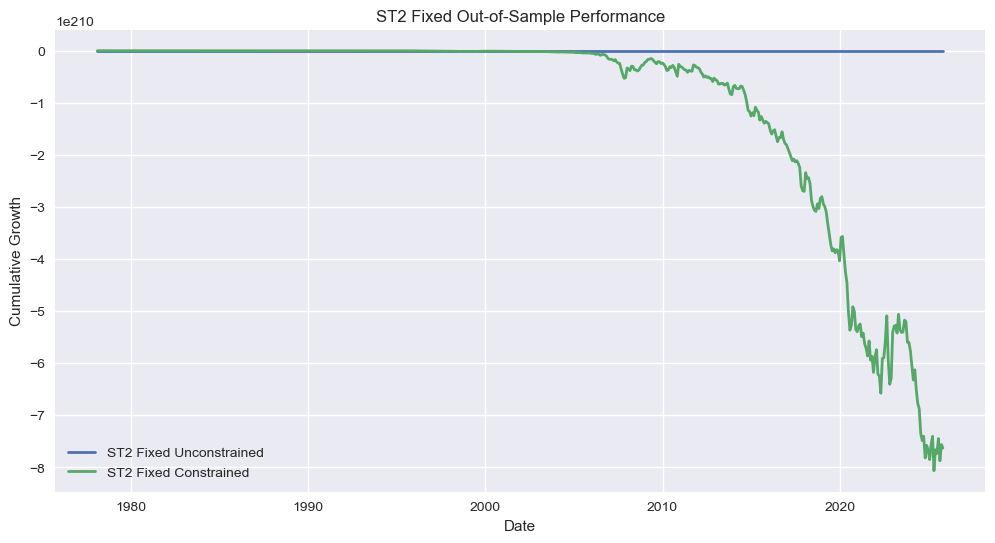

In [29]:
# ============================================
# Figure: ST2 Fixed Performance
# ============================================

st2_cumulative_unconstrained_fix = (
    1 + st2_returns_unconstrained_fix
).cumprod()

st2_cumulative_constrained_fix = (
    1 + st2_returns_constrained_fix
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    st2_cumulative_unconstrained_fix.index,
    st2_cumulative_unconstrained_fix,
    linewidth=2,
    label='ST2 Fixed Unconstrained'
)

plt.plot(
    st2_cumulative_constrained_fix.index,
    st2_cumulative_constrained_fix,
    linewidth=2,
    label='ST2 Fixed Constrained'
)

plt.title('ST2 Fixed Out-of-Sample Performance')

plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()

plt.grid(True)

plt.show()

In [30]:
# ============================================
# Section 11.1: ST2 Dynamic Factor Replacement
# ============================================

st2_data = pd.DataFrame(
    index=vm_data.index,
    columns=data.columns
)

st2_selected_factors = {}

window = 120

for t in range(window, len(vm_data)):

    train_index = vm_data.index[
        t-window:t
    ]

    selected_vm_factors = []

    for factor in data.columns:

        original_sr = sharpe_ratio(
            data.loc[train_index, factor]
        )

        vm_sr = sharpe_ratio(
            vm_data.loc[train_index, factor]
        )

        if vm_sr > original_sr:

            selected_vm_factors.append(
                factor
            )

            st2_data.loc[
                vm_data.index[t],
                factor
            ] = vm_data.loc[
                vm_data.index[t],
                factor
            ]

        else:

            st2_data.loc[
                vm_data.index[t],
                factor
            ] = data.loc[
                vm_data.index[t],
                factor
            ]

    st2_selected_factors[
        vm_data.index[t]
    ] = selected_vm_factors

st2_data = st2_data.dropna()

st2_data.head()


,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
Dates,,,,,,,,,
1978-02-01,-0.013800,0.211070,0.007600,0.006308,0.010400,0.050384,0.001235,0.013206,0.014900
1978-03-01,0.028500,0.151608,0.012000,-0.010480,0.018800,0.036198,-0.000072,0.025349,0.016300
1978-04-01,0.078800,0.015341,-0.035400,0.048036,-0.013500,0.022836,0.089099,-0.003620,0.032100
1978-05-01,0.017600,0.202243,-0.006200,0.004203,0.003600,0.118368,0.003976,0.008898,0.022100
1978-06-01,-0.016900,0.054468,0.005900,-0.022383,-0.000200,0.101627,0.011883,0.004300,0.021000


In [31]:
# ============================================
# ST2 Parametric Portfolio
# ============================================

st2_returns_unconstrained, st2_weights_unconstrained = (
    rolling_oos_performance(
        st2_data,
        window=120,
        constrained=False
    )
)

st2_returns_constrained, st2_weights_constrained = (
    rolling_oos_performance(
        st2_data,
        window=120,
        constrained=True
    )
)

In [32]:
# ============================================
# ST2 Factor Selection Frequency
# ============================================

selection_count = pd.Series(0,index=data.columns)

for factors in st2_selected_factors.values():

    for factor in factors:

        selection_count[factor] += 1

selection_frequency = (
    selection_count /
    len(st2_selected_factors)
)

selection_frequency.sort_values(
    ascending=False
)

ROE      0.899130
UMD      0.751304
BAB      0.438261
RMW      0.386087
HML      0.292174
Market   0.276522
IA       0.212174
SMB      0.208696
CMA      0.203478
dtype: float64

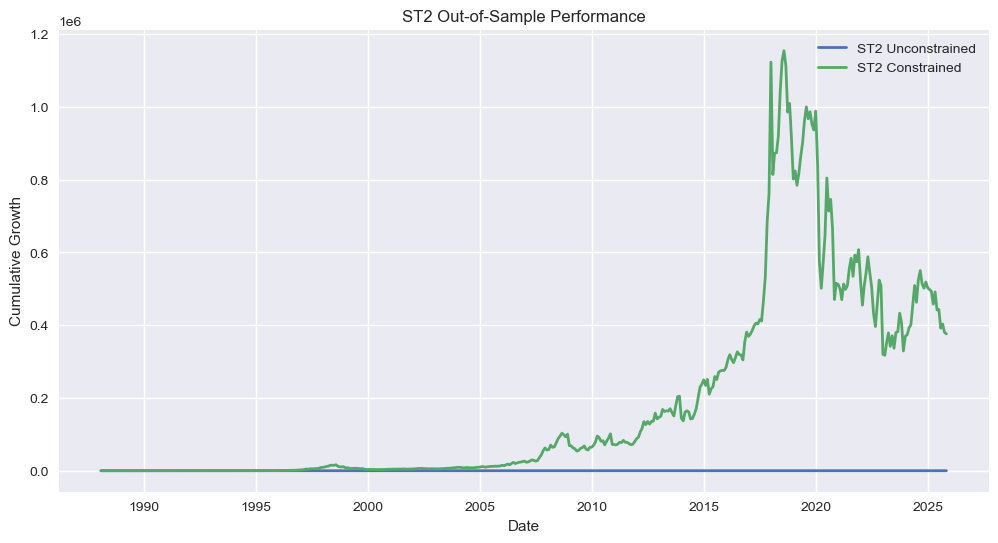

In [33]:

# ============================================
# Figure: ST2 Performance
# ============================================

st2_cumulative_unconstrained = (
    1 + st2_returns_unconstrained
).cumprod()

st2_cumulative_constrained = (
    1 + st2_returns_constrained
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    st2_cumulative_unconstrained.index,
    st2_cumulative_unconstrained,
    linewidth=2,
    label='ST2 Unconstrained'
)

plt.plot(
    st2_cumulative_constrained.index,
    st2_cumulative_constrained,
    linewidth=2,
    label='ST2 Constrained'
)

plt.title('ST2 Out-of-Sample Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()



In [34]:
# ============================================
# OOS Volatility-Managed 1/N Benchmark
# ============================================

vm_equal_weight_oos = vm_data.mean(axis=1)

# align with OOS sample

vm_equal_weight_oos = vm_equal_weight_oos.loc[
    oos_returns_unconstrained_120.index
]

equal_weight_oos = equal_weight_returns.loc[
    oos_returns_unconstrained_120.index
]

In [35]:
# ============================================
# Benchmark Comparison Table
# ============================================

benchmark_table = pd.DataFrame(index=[
    '1/N',
    'VM 1/N'
])

benchmark_table['Mean Return'] = [

    annualized_return(equal_weight_oos),

    annualized_return(vm_equal_weight_oos)

]

benchmark_table['Volatility'] = [

    annualized_volatility(equal_weight_oos),

    annualized_volatility(vm_equal_weight_oos)

]

benchmark_table['Sharpe Ratio'] = [

    sharpe_ratio(equal_weight_oos),

    sharpe_ratio(vm_equal_weight_oos)

]

benchmark_table['Skewness'] = [

    skewness(equal_weight_oos),

    skewness(vm_equal_weight_oos)

]

benchmark_table['Kurtosis'] = [

    kurtosis_value(equal_weight_oos),

    kurtosis_value(vm_equal_weight_oos)

]

benchmark_table.round(4)

,Mean Return,Volatility,Sharpe Ratio,Skewness,Kurtosis
1/N,0.050500,0.041900,1.202700,-0.279800,6.065200
VM 1/N,0.050500,0.038200,1.320600,0.373500,4.191800


In [36]:
# ============================================
# 1/N vs VM 1/N Sharpe Test
# ============================================

benchmark_test = jobson_korkie_test(

    vm_equal_weight_oos,

    equal_weight_oos

)

benchmark_test_table = pd.DataFrame({

    'VM 1/N vs 1/N':

    benchmark_test

}).T

benchmark_test_table['Significance'] = (
    benchmark_test_table['P-Value']
    .apply(significance_stars)
)

benchmark_test_table

,SR1,SR2,SR Difference,Z-Statistic,P-Value,Significance
VM 1/N vs 1/N,1.320595,1.202721,0.117874,2.296873,0.021626,**


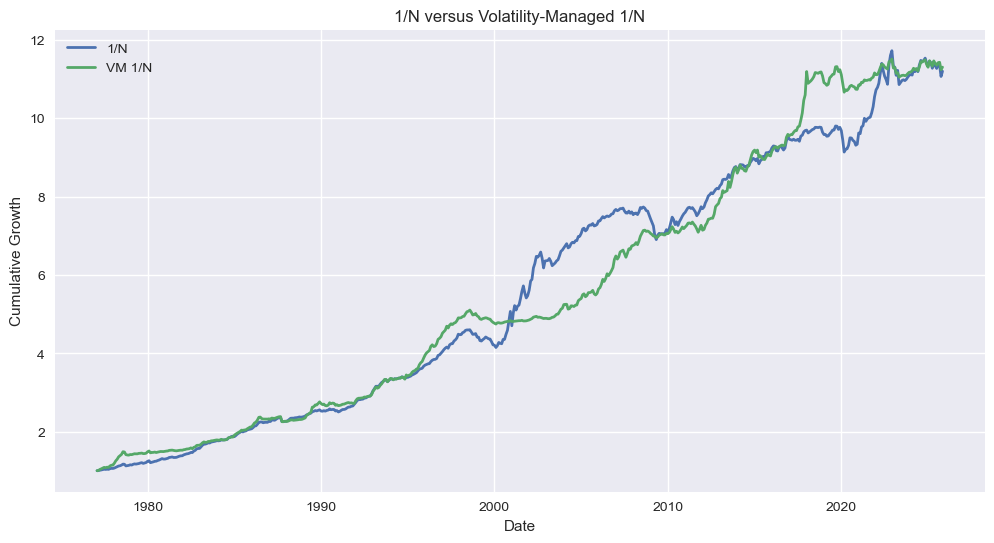

In [37]:
# ============================================
# Figure: Benchmark Comparison
# ============================================

benchmark_cumulative = pd.DataFrame({

    '1/N':
    (1 + equal_weight_oos).cumprod(),

    'VM 1/N':
    (1 + vm_equal_weight_oos).cumprod()

})

plt.figure(figsize=(12,6))

for col in benchmark_cumulative.columns:

    plt.plot(
        benchmark_cumulative.index,
        benchmark_cumulative[col],
        linewidth=2,
        label=col
    )

plt.title('1/N versus Volatility-Managed 1/N')

plt.xlabel('Date')

plt.ylabel('Cumulative Growth')

plt.legend()

plt.grid(True)

plt.show()

In [38]:

# ============================================
# Section 12: Strategy Comparison
# ============================================

strategy_comparison = pd.DataFrame(index=[
    'Original',
    'ST1',
    'ST2',
    'ST2_fix',
    '1/N',
    'VM 1/N'
])

# --------------------------------------------
# Unconstrained OOS Sharpe Ratios
# --------------------------------------------

strategy_comparison['Sharpe Ratio'] = [

    sharpe_ratio(oos_returns_unconstrained_120),

    sharpe_ratio(st1_returns_unconstrained),

    sharpe_ratio(st2_returns_unconstrained),

    sharpe_ratio(st2_returns_unconstrained_fix),

    sharpe_ratio(equal_weight_oos),

    sharpe_ratio(vm_equal_weight_oos)

]

# annualized return

strategy_comparison['Mean Return'] = [

    annualized_return(oos_returns_unconstrained_120),

    annualized_return(st1_returns_unconstrained),

    annualized_return(st2_returns_unconstrained),

    annualized_return(st2_returns_unconstrained_fix),

    annualized_return(equal_weight_oos),

    annualized_return(vm_equal_weight_oos)

]

# annualized volatility

strategy_comparison['Volatility'] = [

    annualized_volatility(oos_returns_unconstrained_120),

    annualized_volatility(st1_returns_unconstrained),

    annualized_volatility(st2_returns_unconstrained),

    annualized_volatility(st2_returns_unconstrained_fix),

    annualized_volatility(equal_weight_oos),

    annualized_volatility(vm_equal_weight_oos)

]

strategy_comparison


,Sharpe Ratio,Mean Return,Volatility
Original,0.986477,0.049356,0.050033
ST1,0.990611,0.057927,0.058476
ST2,0.548431,0.045660,0.083256
ST2_fix,1.259187,0.056628,0.044972
1/N,1.202721,0.050451,0.041947
VM 1/N,1.320595,0.050489,0.038232


In [56]:

# ============================================
# Sharpe Ratio Difference Tests
# ============================================

strategy_tests = pd.DataFrame()

# --------------------------------------------
# ST1 vs Original
# --------------------------------------------

strategy_tests['ST1 vs Original'] = (
    jobson_korkie_test(
        st1_returns_unconstrained,
        oos_returns_unconstrained_120
    )
)

# --------------------------------------------
# ST2 vs Original
# --------------------------------------------

strategy_tests['ST2_fix vs Original'] = (
    jobson_korkie_test(
        st2_returns_unconstrained_fix,
        oos_returns_unconstrained_120
    )
)

# --------------------------------------------
# ST1 vs 1/N
# --------------------------------------------

strategy_tests['ST1 vs VM 1/N'] = (
    jobson_korkie_test(
        st1_returns_unconstrained,
        vm_equal_weight_oos
    )
)

strategy_tests['ST1 vs 1/N'] = (
    jobson_korkie_test(
        st1_returns_unconstrained,
        equal_weight_oos
    )
)

# --------------------------------------------
# ST2 vs 1/N
# --------------------------------------------

strategy_tests['ST2_fix vs VM 1/N'] = (
    jobson_korkie_test(
        st2_returns_unconstrained_fix,
        vm_equal_weight_oos
    )
)


# --------------------------------------------
# ST2 vs ST1
# --------------------------------------------

strategy_tests['ST2_fix vs ST1'] = (
    jobson_korkie_test(
        st2_returns_unconstrained_fix,
        st1_returns_unconstrained
    )
)

# --------------------------------------------
# ST2 vs ST2_fix
# --------------------------------------------

strategy_tests['ST2_fix vs ST2'] = (
    jobson_korkie_test(
        st2_returns_unconstrained_fix,
        st2_returns_unconstrained
    )
)

# --------------------------------------------
# vm 1/N vs 1/N
# --------------------------------------------
strategy_tests['vm 1/N vs 1/N'] = (
    jobson_korkie_test(
        vm_equal_weight_oos,
        equal_weight_oos
    )
)


strategy_tests = strategy_tests.T

strategy_tests['Significance'] = (
    strategy_tests['P-Value']
    .apply(significance_stars)
)

strategy_tests


,SR1,SR2,SR Difference,Z-Statistic,P-Value,Significance
ST1 vs Original,0.993369,0.962654,0.030715,0.700874,0.483381,
ST2_fix vs Original,1.259187,0.962654,0.296533,6.604267,0.000000,***
ST1 vs VM 1/N,0.993369,1.281044,-0.287675,-5.556919,0.000000,***
ST1 vs 1/N,0.993369,1.188561,-0.195192,-3.536286,0.000406,***
ST2_fix vs VM 1/N,1.259187,1.281044,-0.021856,-0.391308,0.695570,
ST2_fix vs ST1,1.259187,0.993369,0.265818,6.897478,0.000000,***
ST2_fix vs ST2,1.091940,0.548431,0.543509,9.734285,0.000000,***
vm 1/N vs 1/N,1.320595,1.202721,0.117874,2.296873,0.021626,**


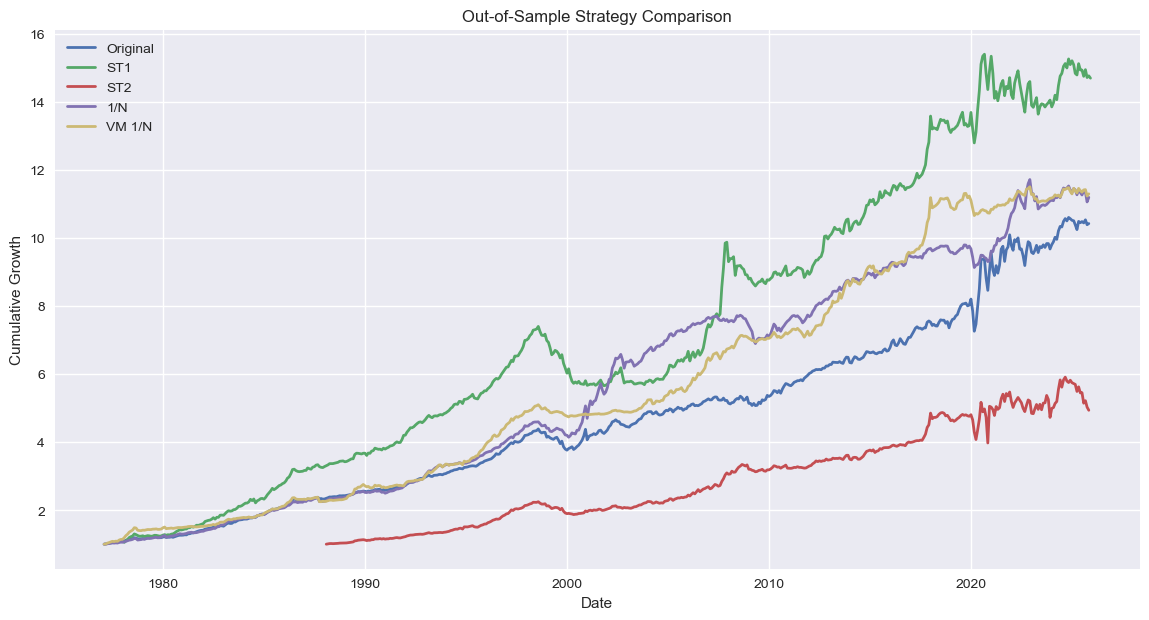

In [49]:

# ============================================
# Figure: Strategy Comparison
# ============================================

comparison_cumulative = pd.DataFrame({

    'Original':
    (1 + oos_returns_unconstrained_120).cumprod(),

    'ST1':
    (1 + st1_returns_unconstrained).cumprod(),

    'ST2':
    (1 + st2_returns_unconstrained).cumprod(),

    '1/N':
    (1 + equal_weight_oos).cumprod(),

    'VM 1/N':
    (1 + vm_equal_weight_oos).cumprod()

})

plt.figure(figsize=(14,7))

for column in comparison_cumulative.columns:

    plt.plot(
        comparison_cumulative.index,
        comparison_cumulative[column],
        linewidth=2,
        label=column
    )

plt.title('Out-of-Sample Strategy Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()


In [41]:

# ============================================
# Section 13: Robustness Analysis
# ============================================

subperiods = {

    'Full Sample':
    data.index,

    'Pre-2008':
    data.loc[data.index < '2008-01-01'].index,

    'Post-2009':
    data.loc[data.index >= '2009-01-01'].index,

    'Post-2020':
    data.loc[data.index >= '2020-01-01'].index

}

rolling_windows = [120, 60, 36]


In [55]:
# ============================================
# Robustness Results
# ============================================

robustness_results = []

robustness_returns = {}

for period_name, period_index in subperiods.items():

    # subset data

    sub_data = data.loc[
        period_index
    ]

    sub_vm_data = vm_data.loc[
        vm_data.index.intersection(period_index)
    ]

    for window in rolling_windows:

        # skip if sample too short

        if len(sub_data) <= window + 12:
            continue

        if len(sub_vm_data) <= window + 12:
            continue

        # ------------------------------------
        # Original Portfolio
        # ------------------------------------

        original_returns, _ = (
            rolling_oos_performance(
                sub_data,
                window=window,
                constrained=False
            )
        )

        # ------------------------------------
        # ST1 Portfolio
        # no look-ahead: combination weights are
        # re-estimated within each rolling window
        # ------------------------------------

        st1_returns, _, _ = (
            rolling_oos_st1(
                sub_data,
                sub_vm_data,
                window=window,
                constrained=False
            )
        )

        # ------------------------------------
        # Equal Weight Benchmark
        # ------------------------------------

        equal_weight = (
            sub_data.mean(axis=1)
        )

        # ------------------------------------
        # VM Equal Weight Benchmark
        # ------------------------------------

        vm_equal_weight = (
            sub_vm_data.mean(axis=1)
        )

        # ====================================
        # Strategy Evaluations
        # ====================================

        strategies = {

            'Original':
            original_returns,

            'ST1':
            st1_returns,

            '1/N':
            equal_weight,

        }

        benchmarks = {

            '1/N':
            equal_weight,

            'VM 1/N':
            vm_equal_weight,

            'Original':
            original_returns

        }

        for strategy_name, strategy_returns in strategies.items():

            # align dates across all strategies and benchmarks

            common_dates = strategy_returns.index

            for benchmark_returns in benchmarks.values():

                common_dates = common_dates.intersection(
                    benchmark_returns.index
                )

            strategy_returns_aligned = strategy_returns.loc[
                common_dates
            ]

            benchmark_1n = equal_weight.loc[
                common_dates
            ]

            benchmark_vm_1n = vm_equal_weight.loc[
                common_dates
            ]

            benchmark_original = original_returns.loc[
                common_dates
            ]

            # skip if too few observations after alignment

            if len(common_dates) < 12:
                continue

            # --------------------------------
            # vs 1/N
            # --------------------------------

            if strategy_name == '1/N':

                diff_vs_1n = 0.0
                p_vs_1n = np.nan
                sig_vs_1n = ''

            else:

                test_1n = jobson_korkie_test(
                    strategy_returns_aligned,
                    benchmark_1n
                )

                diff_vs_1n = test_1n[
                    'SR Difference'
                ]

                p_vs_1n = test_1n[
                    'P-Value'
                ]

                sig_vs_1n = significance_stars(
                    p_vs_1n
                )

            # --------------------------------
            # vs VM 1/N
            # --------------------------------

            if strategy_name == 'VM 1/N':

                diff_vs_vm_1n = 0.0
                p_vs_vm_1n = np.nan
                sig_vs_vm_1n = ''

            else:

                test_vm_1n = jobson_korkie_test(
                    strategy_returns_aligned,
                    benchmark_vm_1n
                )

                diff_vs_vm_1n = test_vm_1n[
                    'SR Difference'
                ]

                p_vs_vm_1n = test_vm_1n[
                    'P-Value'
                ]

                sig_vs_vm_1n = significance_stars(
                    p_vs_vm_1n
                )

            # --------------------------------
            # vs Original
            # --------------------------------

            if strategy_name == 'Original':

                diff_vs_original = 0.0
                p_vs_original = np.nan
                sig_vs_original = ''

            else:

                test_original = jobson_korkie_test(
                    strategy_returns_aligned,
                    benchmark_original
                )

                diff_vs_original = test_original[
                    'SR Difference'
                ]

                p_vs_original = test_original[
                    'P-Value'
                ]

                sig_vs_original = significance_stars(
                    p_vs_original
                )

            # --------------------------------
            # Save Results
            # --------------------------------

            robustness_results.append({

                'Subperiod':
                period_name,

                'Window':
                f'{window}M',

                'Strategy':
                strategy_name,

                'Scenario':
                f'{period_name} | {window}M | {strategy_name}',

                'Sharpe Ratio':
                sharpe_ratio(
                    strategy_returns_aligned
                ),

                'Difference vs 1/N':
                diff_vs_1n,

                'P-Value vs 1/N':
                p_vs_1n,

                'Sig vs 1/N':
                sig_vs_1n,

                'Difference vs VM 1/N':
                diff_vs_vm_1n,

                'P-Value vs VM 1/N':
                p_vs_vm_1n,

                'Sig vs VM 1/N':
                sig_vs_vm_1n,

                'Difference vs Original':
                diff_vs_original,

                'P-Value vs Original':
                p_vs_original,

                'Sig vs Original':
                sig_vs_original,

                'Observations':
                len(common_dates)

            })

            # save aligned returns for plotting

            robustness_returns[
                (
                    period_name,
                    window,
                    strategy_name
                )
            ] = strategy_returns_aligned

        # also save benchmarks for plotting

        common_dates_plot = (
            original_returns.index
            .intersection(equal_weight.index)
            .intersection(vm_equal_weight.index)
        )

        robustness_returns[
            (
                period_name,
                window,
                '1/N'
            )
        ] = equal_weight.loc[
            common_dates_plot
        ]

        robustness_returns[
            (
                period_name,
                window,
                'VM 1/N'
            )
        ] = vm_equal_weight.loc[
            common_dates_plot
        ]

In [57]:
# ============================================
# Robustness Table
# ============================================

robustness_table = pd.DataFrame(
    robustness_results
)

robustness_table = robustness_table.round(
    4
)

robustness_table

,Subperiod,Window,Strategy,Scenario,Sharpe Ratio,Difference vs 1/N,P-Value vs 1/N,Sig vs 1/N,Difference vs VM 1/N,P-Value vs VM 1/N,Sig vs VM 1/N,Difference vs Original,P-Value vs Original,Sig vs Original,Observations
0,Full Sample,120M,Original,Full Sample | 120M | Original,0.986500,-0.216200,0.000000,***,-0.334100,0.000000,***,0.000000,NaN,,586
1,Full Sample,120M,ST1,Full Sample | 120M | ST1,0.993400,-0.195200,0.000400,***,-0.287700,0.000000,***,0.030700,0.483400,,574
2,Full Sample,120M,1/N,Full Sample | 120M | 1/N,1.202700,0.000000,NaN,,-0.117900,0.021600,**,0.216200,0.000000,***,586
3,Full Sample,60M,Original,Full Sample | 60M | Original,-0.002100,-1.233300,0.000000,***,-1.291200,0.000000,***,0.000000,NaN,,646
4,Full Sample,60M,ST1,Full Sample | 60M | ST1,0.207200,-1.015300,0.000000,***,-1.076300,0.000000,***,0.212800,0.000200,***,634
5,Full Sample,60M,1/N,Full Sample | 60M | 1/N,1.231200,0.000000,NaN,,-0.057900,0.234800,,1.233300,0.000000,***,646
6,Full Sample,36M,Original,Full Sample | 36M | Original,0.351300,-0.886300,0.000000,***,-0.922100,0.000000,***,0.000000,NaN,,670
7,Full Sample,36M,ST1,Full Sample | 36M | ST1,0.121500,-1.110800,0.000000,***,-1.155300,0.000000,***,-0.229900,0.000000,***,658
8,Full Sample,36M,1/N,Full Sample | 36M | 1/N,1.237600,0.000000,NaN,,-0.035700,0.451400,,0.886300,0.000000,***,670
9,Pre-2008,120M,Original,Pre-2008 | 120M | Original,1.489000,-0.035500,0.521300,,-0.055800,0.447200,,0.000000,NaN,,370


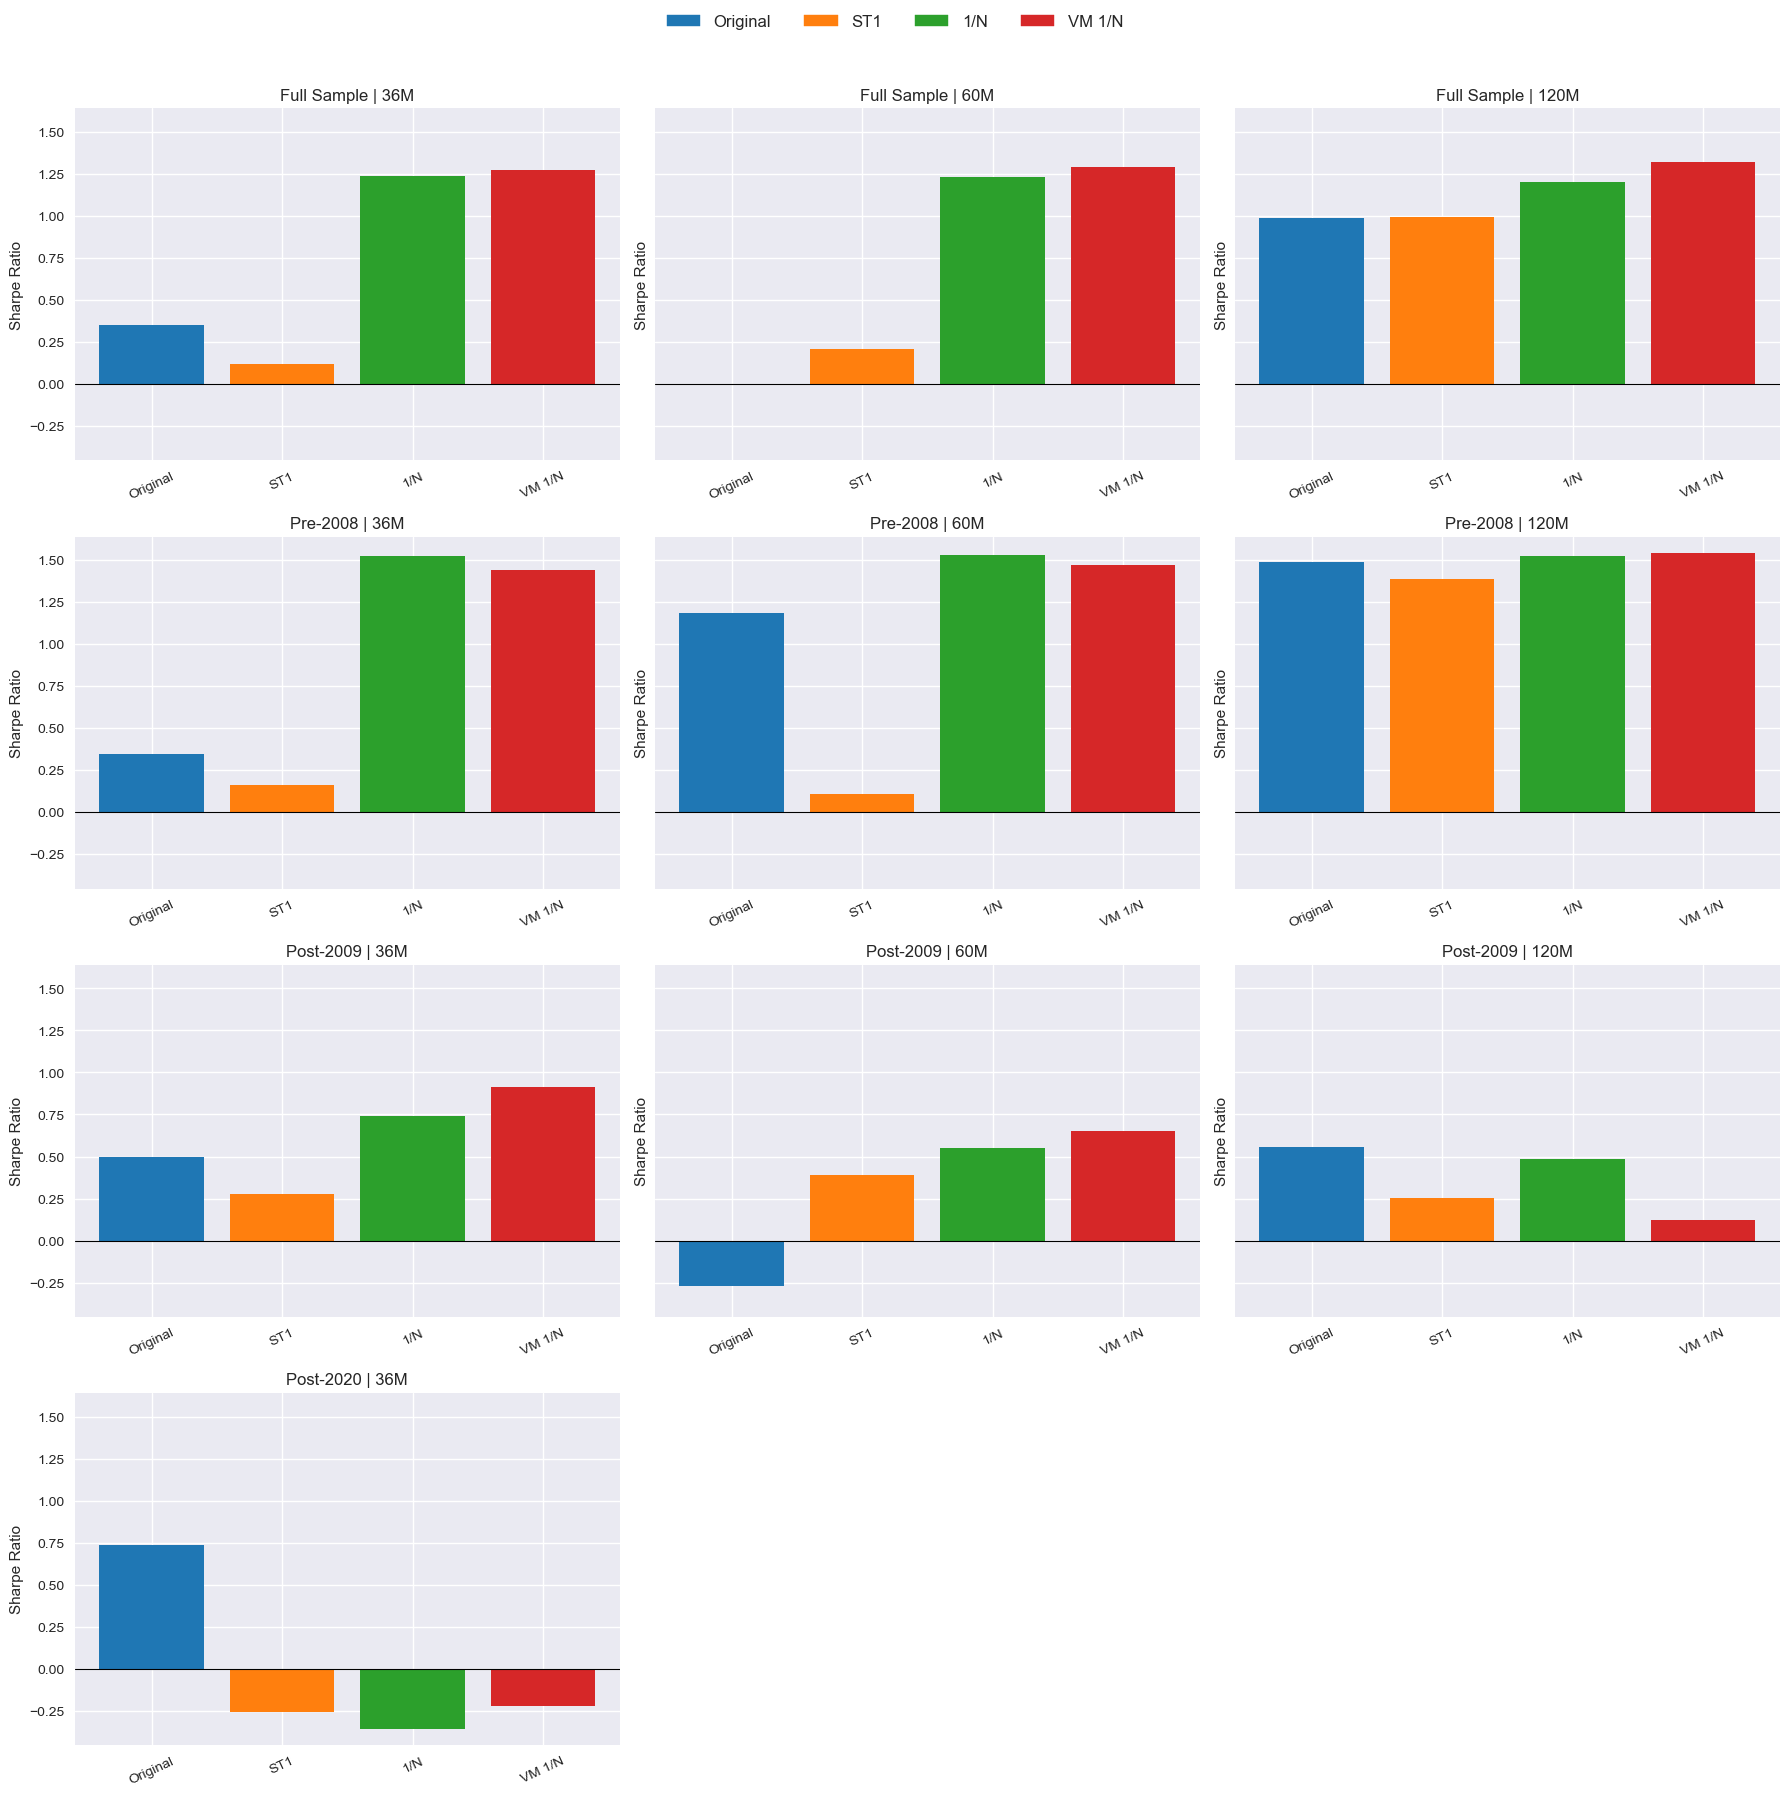

In [44]:
# ============================================
# Figure: Robustness Sharpe Ratios
# ============================================

plot_subperiods = [
    'Full Sample',
    'Pre-2008',
    'Post-2009',
    'Post-2020'
]

plot_windows = [
    36,
    60,
    120
]

plot_strategies = [
    'Original',
    'ST1',
    '1/N',
    'VM 1/N'
]

strategy_colors = {
    'Original': 'tab:blue',
    'ST1': 'tab:orange',
    '1/N': 'tab:green',
    'VM 1/N': 'tab:red'
}

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18,18),
    sharey=True
)

for i, period_name in enumerate(plot_subperiods):

    for j, window in enumerate(plot_windows):

        ax = axes[i, j]

        sharpe_values = []

        available_strategies = []

        for strategy in plot_strategies:

            key = (
                period_name,
                window,
                strategy
            )

            if key in robustness_returns:

                temp_returns = robustness_returns[
                    key
                ]

                sharpe_values.append(
                    sharpe_ratio(temp_returns)
                )

                available_strategies.append(
                    strategy
                )

        if len(available_strategies) == 0:

            ax.axis('off')
            continue

        bar_colors = [
            strategy_colors[strategy]
            for strategy in available_strategies
        ]

        ax.bar(
            available_strategies,
            sharpe_values,
            color=bar_colors
        )

        ax.set_title(
            f'{period_name} | {window}M'
        )

        ax.set_ylabel(
            'Sharpe Ratio'
        )

        ax.grid(
            True,
            axis='y'
        )

        ax.tick_params(
            axis='x',
            rotation=25
        )

        # add horizontal zero line

        ax.axhline(
            0,
            linewidth=0.8,
            color='black'
        )

# --------------------------------------------
# Global Legend
# --------------------------------------------

handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=strategy_colors[strategy]
    )
    for strategy in plot_strategies
]

fig.legend(
    handles,
    plot_strategies,
    loc='upper center',
    ncol=4,
    fontsize=12
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

In [45]:
# ============================================
# Section 14: VIX Regime Analysis
# ============================================

# --------------------------------------------
# Load Daily VIX Data
# --------------------------------------------

vix_daily = pd.read_csv('VIXCLS.csv')

vix_daily['date'] = pd.to_datetime(
    vix_daily['date'],
    errors='coerce'
)

vix_daily['VIX'] = pd.to_numeric(
    vix_daily['VIX'],
    errors='coerce'
)

vix_daily = vix_daily.dropna(
    subset=['date', 'VIX']
)

vix_daily = vix_daily.sort_values(
    'date'
)

vix_daily = vix_daily.set_index(
    'date'
)

# --------------------------------------------
# Convert Daily VIX to Monthly VIX
# --------------------------------------------

vix_monthly = (
    vix_daily['VIX']
    .resample('M')
    .mean()
)

vix_monthly.index = (
    vix_monthly.index
    .to_period('M')
    .to_timestamp()
)

# --------------------------------------------
# Strategy Returns for Regime Analysis
# --------------------------------------------

regime_returns = pd.DataFrame({

    'Original':
    oos_returns_unconstrained_120,

    'ST1':
    st1_returns_unconstrained,

    'ST2':
    st2_returns_unconstrained,

    '1/N':
    equal_weight_oos,

    'VM 1/N':
    vm_equal_weight_oos

})

regime_returns = regime_returns.dropna()

# --------------------------------------------
# Align Monthly VIX with Strategy Returns
# --------------------------------------------

common_dates = regime_returns.index.intersection(
    vix_monthly.index
)

regime_returns = regime_returns.loc[
    common_dates
]

regime_vix = vix_monthly.loc[
    common_dates
]

regime_data = regime_returns.copy()

regime_data['VIX'] = regime_vix

regime_data = regime_data.dropna()

# --------------------------------------------
# Define VIX Regimes by Terciles
# --------------------------------------------

regime_data['VIX Regime'] = pd.qcut(
    regime_data['VIX'],
    q=3,
    labels=[
        'Low VIX',
        'Medium VIX',
        'High VIX'
    ]
)

# --------------------------------------------
# Performance by VIX Regime
# --------------------------------------------

vix_regime_results = []

for regime in [
    'Low VIX',
    'Medium VIX',
    'High VIX'
]:

    temp = regime_data[
        regime_data['VIX Regime'] == regime
    ]

    benchmark_1n = temp['1/N']
    benchmark_vm_1n = temp['VM 1/N']
    benchmark_original = temp['Original']

    for strategy in [
        'Original',
        'ST1',
        '1/N',
        'VM 1/N'
    ]:

        strategy_return = temp[strategy]

        # ------------------------------------
        # vs 1/N
        # ------------------------------------

        if strategy == '1/N':

            diff_vs_1n = 0.0
            p_vs_1n = np.nan
            sig_vs_1n = ''

        else:

            test_vs_1n = jobson_korkie_test(
                strategy_return,
                benchmark_1n
            )

            diff_vs_1n = test_vs_1n[
                'SR Difference'
            ]

            p_vs_1n = test_vs_1n[
                'P-Value'
            ]

            sig_vs_1n = significance_stars(
                p_vs_1n
            )

        # ------------------------------------
        # vs VM 1/N
        # ------------------------------------

        if strategy == 'VM 1/N':

            diff_vs_vm_1n = 0.0
            p_vs_vm_1n = np.nan
            sig_vs_vm_1n = ''

        else:

            test_vs_vm_1n = jobson_korkie_test(
                strategy_return,
                benchmark_vm_1n
            )

            diff_vs_vm_1n = test_vs_vm_1n[
                'SR Difference'
            ]

            p_vs_vm_1n = test_vs_vm_1n[
                'P-Value'
            ]

            sig_vs_vm_1n = significance_stars(
                p_vs_vm_1n
            )

        # ------------------------------------
        # vs Original
        # ------------------------------------

        if strategy == 'Original':

            diff_vs_original = 0.0
            p_vs_original = np.nan
            sig_vs_original = ''

        else:

            test_vs_original = jobson_korkie_test(
                strategy_return,
                benchmark_original
            )

            diff_vs_original = test_vs_original[
                'SR Difference'
            ]

            p_vs_original = test_vs_original[
                'P-Value'
            ]

            sig_vs_original = significance_stars(
                p_vs_original
            )

        vix_regime_results.append({

            'VIX Regime':
            regime,

            'Strategy':
            strategy,

            'Mean Return':
            annualized_return(
                strategy_return
            ),

            'Volatility':
            annualized_volatility(
                strategy_return
            ),

            'Sharpe Ratio':
            sharpe_ratio(
                strategy_return
            ),

            'Difference vs 1/N':
            diff_vs_1n,

            'P-Value vs 1/N':
            p_vs_1n,

            'Sig vs 1/N':
            sig_vs_1n,

            'Difference vs VM 1/N':
            diff_vs_vm_1n,

            'P-Value vs VM 1/N':
            p_vs_vm_1n,

            'Sig vs VM 1/N':
            sig_vs_vm_1n,

            'Difference vs Original':
            diff_vs_original,

            'P-Value vs Original':
            p_vs_original,

            'Sig vs Original':
            sig_vs_original,

            'Skewness':
            skewness(
                strategy_return
            ),

            'Kurtosis':
            kurtosis_value(
                strategy_return
            ),

            'Observations':
            len(temp)

        })

vix_regime_table = pd.DataFrame(
    vix_regime_results
)

vix_regime_table = vix_regime_table.round(4)

vix_regime_table

,VIX Regime,Strategy,Mean Return,Volatility,Sharpe Ratio,Difference vs 1/N,P-Value vs 1/N,Sig vs 1/N,Difference vs VM 1/N,P-Value vs VM 1/N,Sig vs VM 1/N,Difference vs Original,P-Value vs Original,Sig vs Original,Skewness,Kurtosis,Observations
0,Low VIX,Original,0.046000,0.028600,1.610100,-0.249500,0.059500,*,-0.228400,0.116300,,0.000000,NaN,,-0.425300,0.692600,144
1,Low VIX,ST1,0.074700,0.044900,1.664600,-0.194900,0.187700,,-0.173900,0.147300,,0.054500,0.650200,,0.129500,3.153300,144
2,Low VIX,1/N,0.045300,0.024300,1.859500,0.000000,NaN,,0.021100,0.838200,,0.249500,0.059500,*,0.138000,0.569400,144
3,Low VIX,VM 1/N,0.072100,0.039200,1.838500,-0.021100,0.838200,,0.000000,NaN,,0.228400,0.116300,,0.664200,2.075300,144
4,Medium VIX,Original,0.057300,0.041600,1.377300,-0.134100,0.253900,,-0.139200,0.288800,,0.000000,NaN,,-0.594600,4.372500,143
5,Medium VIX,ST1,0.044800,0.051600,0.867700,-0.643600,0.000000,***,-0.648700,0.000000,***,-0.509500,0.000000,***,-0.527500,4.273200,143
6,Medium VIX,1/N,0.053900,0.035600,1.511400,0.000000,NaN,,-0.005100,0.961200,,0.134100,0.253900,,-0.278700,4.431600,143
7,Medium VIX,VM 1/N,0.048300,0.031800,1.516400,0.005100,0.961200,,0.000000,NaN,,0.139200,0.288800,,-0.160300,0.901600,143
8,High VIX,Original,0.018600,0.080600,0.231000,-0.205200,0.011900,**,0.257500,0.003800,***,0.000000,NaN,,0.386600,3.653100,144
9,High VIX,ST1,0.002000,0.074600,0.026900,-0.409300,0.000000,***,0.053400,0.537700,,-0.204100,0.004400,***,0.898800,3.956700,144


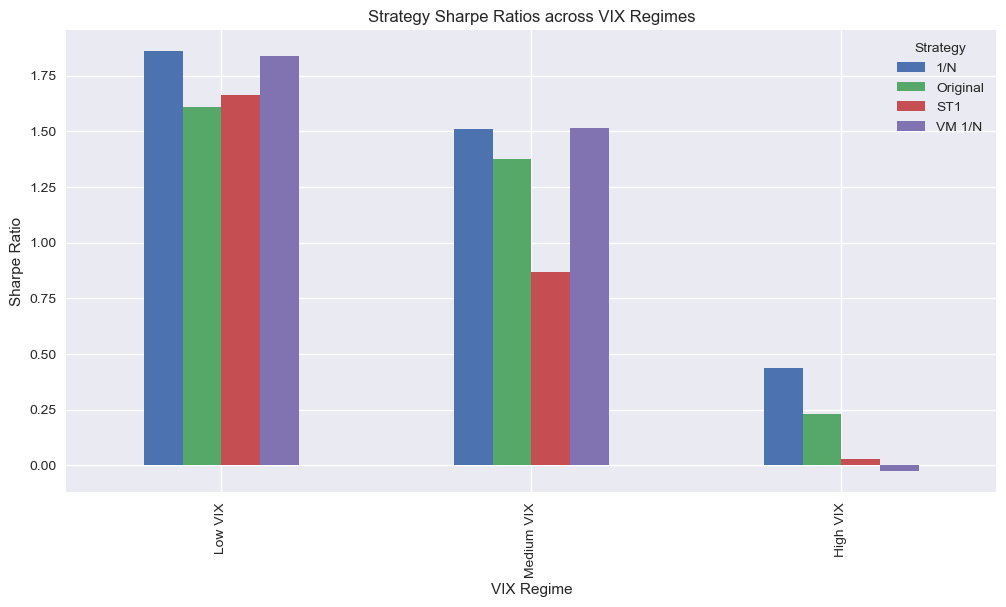

In [46]:
# ============================================
# Figure: Sharpe Ratios by VIX Regime
# ============================================

vix_regime_pivot = vix_regime_table.pivot(
    index='VIX Regime',
    columns='Strategy',
    values='Sharpe Ratio'
)

vix_regime_pivot = vix_regime_pivot.loc[
    [
        'Low VIX',
        'Medium VIX',
        'High VIX'
    ]
]

vix_regime_pivot.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Strategy Sharpe Ratios across VIX Regimes'
)

plt.xlabel(
    'VIX Regime'
)

plt.ylabel(
    'Sharpe Ratio'
)

plt.grid(
    True
)

plt.legend(
    title='Strategy'
)

plt.show()

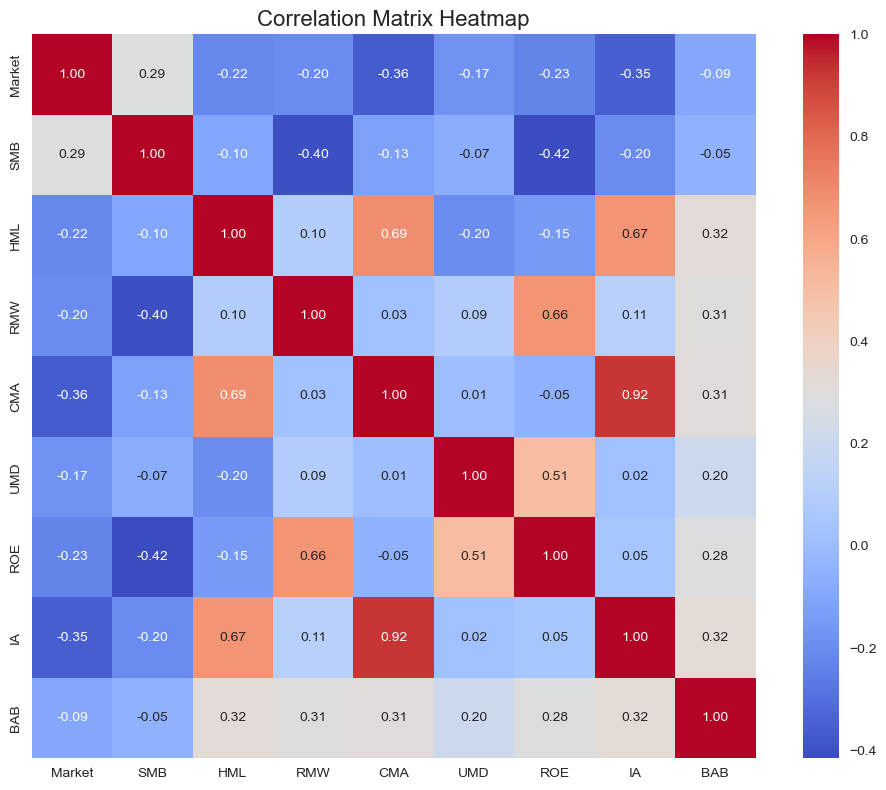

In [47]:
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = data.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,          # Correlation matrix
    annot=True,                  # Annotate cells with correlation coefficients
    fmt=".2f",                   # Format for annotations (2 decimal places)
    cmap="coolwarm",             # Color map
    cbar=True,                   # Include color bar
    square=True                  # Make cells square
)

# Add title
plt.title("Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

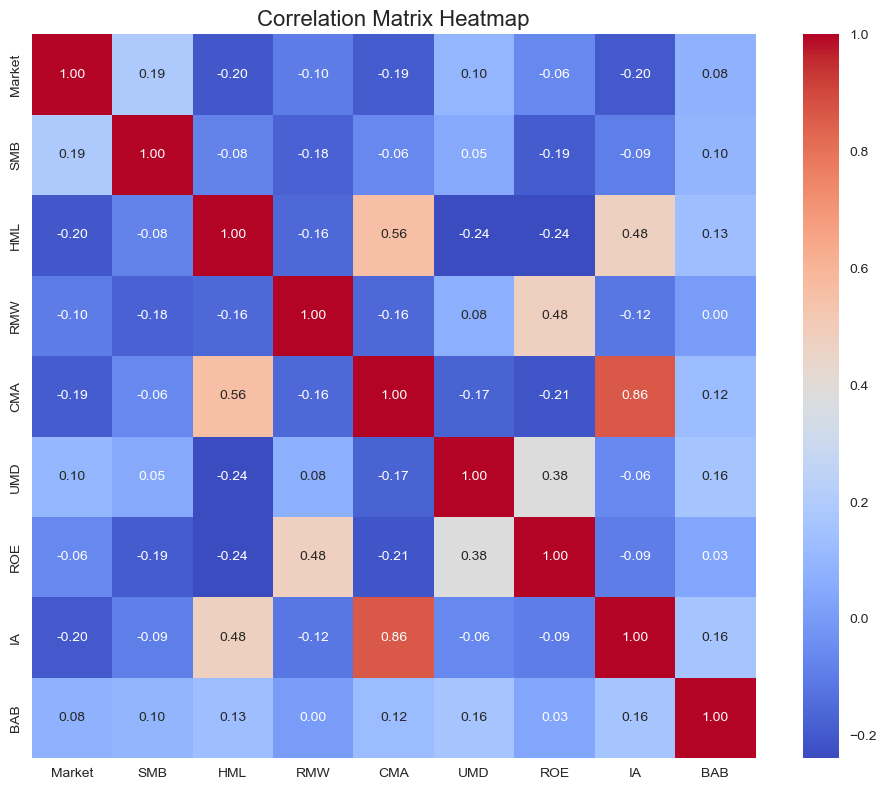

In [48]:
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = vm_data.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,          # Correlation matrix
    annot=True,                  # Annotate cells with correlation coefficients
    fmt=".2f",                   # Format for annotations (2 decimal places)
    cmap="coolwarm",             # Color map
    cbar=True,                   # Include color bar
    square=True                  # Make cells square
)

# Add title
plt.title("Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()